In [142]:
import os
import sys
from datetime import datetime

from importlib import reload
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utils')
os.chdir(current_dir)
if utilities_dir not in sys.path:
    sys.path.insert(0, utilities_dir)
import plotting
import pinns
import infinite
reload(plotting)
reload(pinns)
reload(infinite)
import numpy as np
import sympy as sp
import pickle
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn
import torch.optim as optim
from pinns import  MLP, init_weights, CoefficientNet, pde_loss_inf, observation_loss_u, observation_loss_k, train_dual_network, build_models, set_seed,run_experiment_inf,build_models_KAN
from infinite import analytical_solution_inf, coefficient_inf, source_term_inf, generate_dataset_inf, evaluate_model_inf
torch.set_default_dtype(torch.float32)
from plotting import plot_histories_comparison

set_seed(1)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [143]:
(
    X_obs,
    U_obs,
    X_obs_k,
    K_obs,
    X_pde,
    F_pde,
    X,
    Y,
    U,
    K,
) = generate_dataset_inf(
    sigma=2.0,
    sampling="gaussian",
    n_obs_u=100,
    n_obs_k=100,
    n_pde=1000,
    plot=False,
    device=device,
    seed=2,
)

In [144]:
model_u, model_k = build_models_KAN(
    device,
    hidden_units=25,
    grid_size=5,
    spline_order=3,
)

# --------------------------------------------------
# Load trained weights
# --------------------------------------------------

run_dir = (
    "results/"
    "2026-08-31_14-52-37_gaussian_sigma2_adaptive_sched_no_reg"
)

model_u.load_state_dict(
    torch.load(
        f"{run_dir}/model_u.pt",
        map_location=device,
    )
)

model_k.load_state_dict(
    torch.load(
        f"{run_dir}/model_k.pt",
        map_location=device,
    )
)


<All keys matched successfully>

In [145]:
(
    X_obs,
    U_obs,
    X_obs_k,
    K_obs,
    X_pde,
    F_pde,
    X,
    Y,
    U,
    K,
) = generate_dataset_inf(
    sigma=2.0,
    sampling="gaussian",
    n_obs_u=100,
    n_obs_k=100,
    n_pde=1000,
    plot=False,
    device=device,
    seed=2,
)


Spatial generalization
Training domain : [-5, 5] × [-5, 5]
Evaluation domain : [-8, 8] × [-8, 8]

Global relative L2 error
u : 4.796e+00
k : 6.501e-02

Inside training domain
u : 1.670e-01
k : 6.230e-03

Outside training domain
u : 2.575e+06
k : 8.234e-02
Prediction plot saved to: results/gaussian_spatial_generalization.pdf


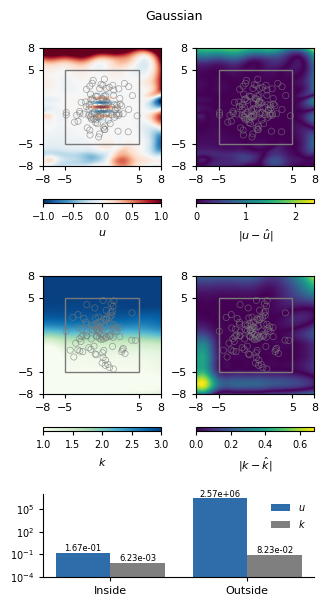

In [146]:
results = evaluate_model_inf(
    model_u=model_u,
    model_k=model_k,

    analytical_solution=analytical_solution_inf,
    coefficient=coefficient_inf,

    X_obs=X_obs,
    X_obs_k=X_obs_k,

    sampling="Gaussian",

    # Training domain
    train_xmin=-5,
    train_xmax=5,
    train_ymin=-5,
    train_ymax=5,

    # Larger domain used ONLY for evaluation
    eval_xmin=-8,
    eval_xmax=8,
    eval_ymin=-8,
    eval_ymax=8,

    n_grid=400,

    alpha=0.5,
    beta=5.0,
    epsilon=1.0,

    device=device,

    plot=True,
    verbose=True,

    save_results=False,
    results_dir="results",

    save_plot=True,
    plot_path="results/gaussian_spatial_generalization.pdf",
)